# Radial Basis Functions

Radial basis functions are an n-dimensional interpolation technique that doesn't rely on polynomials. Rather, we define a radial basis function, called a *kernel*, applied to each data point:

$$\varphi_i(||x-x_i||)$$

Commonly, we say $\varphi_i(x=x_i)\equiv 1$.

The kernel only depends on the Euclidian distance between the associated data point, $x_i$ and the evaluation point $x$ (and are therefore *radial*).  

The interpolation function $y(x)$ is the weighted sum of the $N$ kernels:

$$y(x) = \sum_i^N \omega_i \varphi_i(||x-x_i||)$$

To determine the weights $w_i$, we use the data points we have. Consider the $i$'th datapoints,

$$y(x_i) = \sum_j^N \omega_j \varphi_j(||x-x_j||)=y_i$$

and applied to all N data points generates a linear system:

$$
\begin{bmatrix}
\phi(\|x_1 - x_1\|) & \phi(\|x_1 - x_2\|) & \cdots & \phi(\|x_1 - x_n\|) \\
\phi(\|x_2 - x_1\|) & \phi(\|x_2 - x_2\|) & \cdots & \phi(\|x_2 - x_n\|) \\
\vdots & \vdots & \ddots & \vdots \\
\phi(\|x_n - x_1\|) & \phi(\|x_n - x_2\|) & \cdots & \phi(\|x_n - x_n\|)
\end{bmatrix}  \begin{bmatrix}
\omega_1 \\
\omega_2 \\
\vdots \\
\omega_n
\end{bmatrix} = \begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix}
$$

which we know how to solve!

Kernels are defined with $r = \| x-x_i\|$ and a tuning parameter $\epsilon$. Some common simple kernels are:

| Kernel |                   Formula          |
|---|-----------------------|
| Gaussian |  $e^{-\epsilon^2 r^2}$ |
| Inverse quadratic | $\frac{1}{1+[\epsilon r ]^2}$ |
| Inverse multiquadric | $\frac{1}{\sqrt{1+[\epsilon r ]^2}}$ |

Determination of optimal $\epsilon$ is a nuanced question, but a good rule of thumb is to use the average distance between samples.

$\epsilon = \frac{1}{avg \|x_i-x_j\|}$

We will see that its choice has a large effect on the condition number of the matrix, and therefore the numerical robustness!


Let's see the kernels:

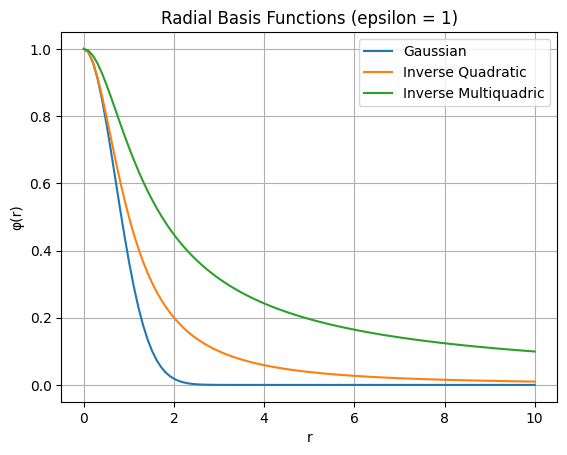

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the radial basis functions
def gaussian(r, epsilon):
  return np.exp(-(epsilon * r)**2)

def inverse_quadratic(r, epsilon):
  return 1 / (1 + (epsilon * r)**2)

def inverse_multiquadric(r, epsilon):
  return 1 / np.sqrt(1 + (epsilon * r)**2)

epsilon = 1

# Create a range of r values
r_values = np.linspace(0, 10, 100)

# Calculate the function values for each kernel
gaussian_values = gaussian(r_values, epsilon)
inverse_quadratic_values = inverse_quadratic(r_values, epsilon)
inverse_multiquadric_values = inverse_multiquadric(r_values, epsilon)

# Plot the radial basis functions
plt.plot(r_values, gaussian_values, label='Gaussian')
plt.plot(r_values, inverse_quadratic_values, label='Inverse Quadratic')
plt.plot(r_values, inverse_multiquadric_values, label='Inverse Multiquadric')

plt.xlabel('r')
plt.ylabel('φ(r)')
plt.title('Radial Basis Functions (epsilon = 1)')
plt.legend()
plt.grid(True)
plt.show()

For these kernels, the influence of a data point diminishes the further from them you get. 

> In general, $\varphi_i(r=0)$ is not necessarily $1$, and $\varphi(r \rightarrow \infty) \ne 0$, but this requires one more key factor to implement robustly.

#### Example - Our Toy problem from last lecture (Gaussian sampled at 10 points, equally spaced)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function
def f(x):
  return np.exp(-(x/2)**2)

def gaussian(r, epsilon):
  return np.exp(-(epsilon * r)**2)

# Create x values for plotting
x_toy = np.linspace(-6, 6, 100)
y_toy = f(x_toy)

# Sample 11 times at 1-interval intervals
x_d = np.arange(-5, 6, 1)
y_d = f(x_d)

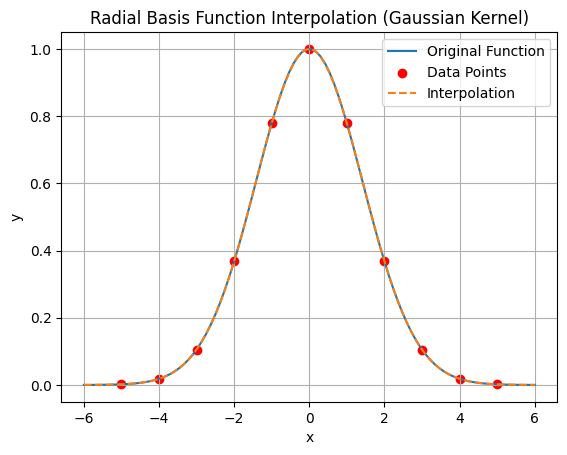

In [4]:
import matplotlib.pyplot as plt
import numpy as np
# Create a matrix of the radial basis functions
phi_matrix = np.zeros((len(x_d), len(x_d)))

epsilon = 1

for i in range(len(x_d)):
  for j in range(len(x_d)):
    phi_matrix[i, j] = gaussian(np.abs(x_d[i] - x_d[j]), epsilon)

#~~ How do we solve for w_i?
# Take a look at the matrix!



# #~~ Answer
# np.set_printoptions(precision=2, suppress=True)
# print(phi_matrix)
weights = np.linalg.solve(phi_matrix, y_d)
# #~~

# Define the interpolation function
def interpolation_function(x, weights, x_d, epsilon):
  y = 0
  for i in range(len(x_d)):
    y += weights[i] * gaussian(np.abs(x - x_d[i]), epsilon)
  return y

# Interpolate y_fit
y_fit = [interpolation_function(x, weights, x_d, epsilon) for x in x_toy]

# Plot the results
plt.plot(x_toy, y_toy, label='Original Function')
plt.scatter(x_d, y_d, color='red', label='Data Points')
plt.plot(x_toy, y_fit, label='Interpolation', linestyle='--')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Radial Basis Function Interpolation (Gaussian Kernel)')
plt.legend()
plt.grid(True)
plt.show()


Note this is a great result, but it works because the true function tends to zero outside of the data samples.

#### Example - 2D gaussian

In [ ]:
import numpy as np
import plotly.graph_objects as go

# Define the target function
def f(x, y):
    return np.exp(-.5*x**2 - .2*y**2) * np.sin(x) * np.cos(.5*y)

x_grid_vals = np.linspace(-3, 3, 100)
y_grid_vals = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x_grid_vals, y_grid_vals)
Z_true = f(X, Y)

num_samples = 100
x_samples = np.random.uniform(-3, 3, num_samples)
y_samples = np.random.uniform(-3, 3, num_samples)
z_samples = f(x_samples, y_samples)

def gaussian_rbf(r, epsilon):
    return np.exp(-(epsilon * r)**2)

dist_matrix = np.sqrt((x_samples[:, np.newaxis] - x_samples)**2 + (y_samples[:, np.newaxis] - y_samples)**2)
average_distance = np.mean(dist_matrix)
eps = 1 / average_distance
print(f"Using epsilon = {eps:.4f}")

phi_matrix = gaussian_rbf(dist_matrix, eps)

print(f'The matrix condition number is, {np.linalg.cond(phi_matrix):.2e}')

weights = np.linalg.solve(phi_matrix, z_samples)

Z_fit = np.zeros_like(X)
for i in range(num_samples):
    r = np.sqrt((X - x_samples[i])**2 + (Y - y_samples[i])**2)
    Z_fit += weights[i] * gaussian_rbf(r, eps)


surface_true = go.Surface(x=X, y=Y, z=Z_true, colorscale='Blues', showscale=False, name='Original')
surface_fit = go.Surface(x=X, y=Y, z=Z_fit, colorscale='Viridis', showscale=False, name='RBF Fit')
scatter_samples = go.Scatter3d(
    x=x_samples, y=y_samples, z=z_samples,
    mode='markers', marker=dict(color='red', size=3), name='Samples'
)

# Plot 1: Original Function
fig_original = go.Figure(data=[surface_true, scatter_samples])
fig_original.update_layout(
    title='Original Function and Data Samples',
    scene=dict(
        xaxis_title='x', yaxis_title='y', zaxis_title='z',
        aspectmode='manual',
        zaxis=dict(range=[-.7, .7]),
        aspectratio=dict(x=1, y=1, z=0.5)
    )
)
print("Displaying the original function...")
fig_original.show()

# Plot 2: RBF Interpolation
fig_fit = go.Figure(data=[surface_fit, scatter_samples])
fig_fit.update_layout(
    title='RBF Interpolated Fit and Data Samples',
    scene=dict(
        xaxis_title='x', yaxis_title='y', zaxis_title='z',
        zaxis=dict(range=[-.7, .7]),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.5)
    )
)
print("Displaying the RBF fitted function...")
fig_fit.show()


Using epsilon = 1.0000
The matrix condition number is, 1.93e+06
Displaying the original function...


Displaying the RBF fitted function...
